<a href="https://colab.research.google.com/github/mzaib1012/Battery-Pack-EKF-SoC-Estimator/blob/main/notebooks/battery_ekf_soc_estimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

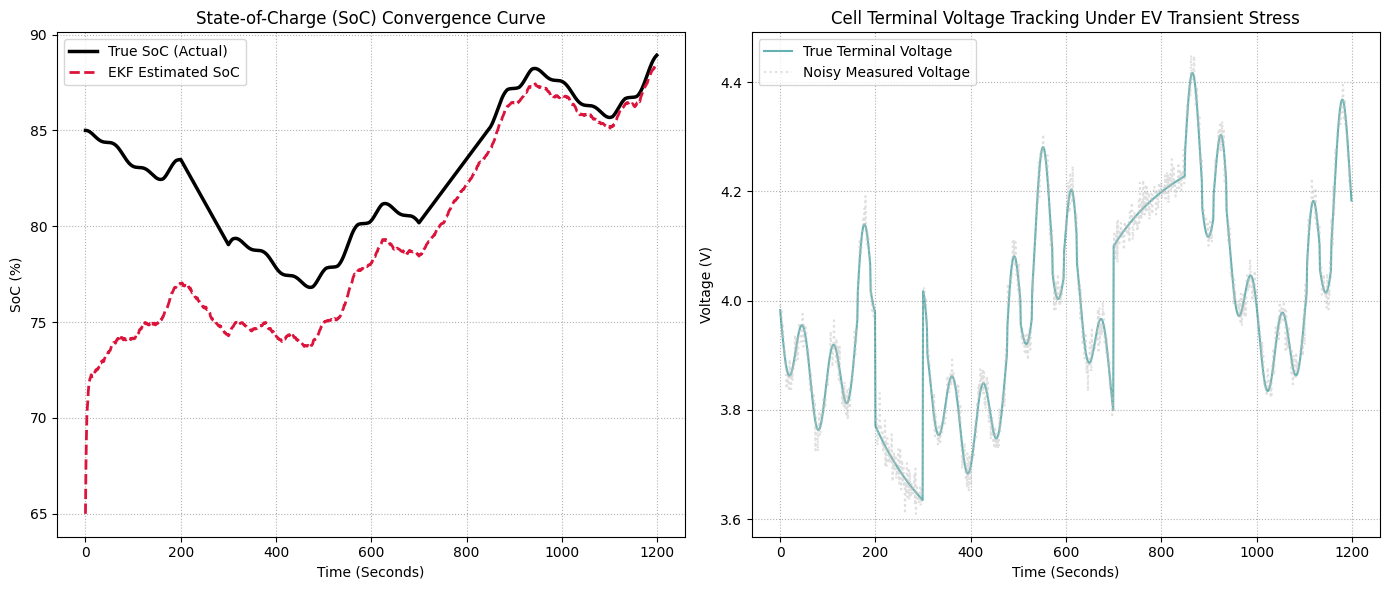

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Battery Cell Parameters (LG Chem 18650 Linearized Profile) ---
Nominal_Cap = 2.5 * 3600  # 2.5 Ah converted to Ampere-seconds (Coulombs)
R0 = 0.05                 # Ohmic internal resistance (Ohms)
R1 = 0.04                 # Charge transfer resistance (Ohms)
C1 = 2500                 # Polarization capacitance (Farads)
dt = 1.0                  # Time step (1 second)

# Non-linear OCV-vs-SoC lookup curve mapping
def soc_to_ocv(soc):
    # Curve-fit approximation of a standard NMC Li-ion cell chemistry
    return 3.1 + 0.9 * soc + 0.1 * np.sin(soc * np.pi) + 0.1 * (soc ** 2)

# Derivative of OCV with respect to SoC (Required for EKF Jacobian matrix calculation)
def d_ocv_d_soc(soc):
    return 0.9 + 0.1 * np.pi * np.cos(soc * np.pi) + 0.2 * soc

# --- 2. Synthetic Dynamic Driving Profile Generation ---
np.random.seed(42)
time_steps = 1200  # 20 minutes duration
time = np.arange(time_steps)

# Generate a high-transient, pulse-like EV current demand profile
current_profile = 2.0 * np.sin(time / 50) + 1.5 * np.sin(time / 10)
current_profile[current_profile < -1.0] *= 1.8  # Inject sudden regenerative braking spikes
current_profile[200:300] = 4.0                 # Constant current discharge pulse
current_profile[700:850] = -3.0                # Sustained charging pulse

# True Battery State Initialization
true_soc = np.zeros(time_steps)
true_V1 = np.zeros(time_steps)
true_Vt = np.zeros(time_steps)

true_soc[0] = 0.85  # Starts at 85% charge
true_V1[0] = 0.0

# True State Forward Projection
for k in range(1, time_steps):
    ik = current_profile[k-1]
    # Standard state equations
    true_soc[k] = true_soc[k-1] - (dt / Nominal_Cap) * ik
    true_V1[k] = np.exp(-dt / (R1 * C1)) * true_V1[k-1] + R1 * (1 - np.exp(-dt / (R1 * C1))) * ik
    true_Vt[k-1] = soc_to_ocv(true_soc[k-1]) - true_V1[k-1] - R0 * ik
true_Vt[-1] = soc_to_ocv(true_soc[-1]) - true_V1[-1] - R0 * current_profile[-1]

# Corrupt voltage measurements with Gaussian noise to simulate cheap automotive sensors
voltage_noise = 0.02
measured_Vt = true_Vt + np.random.normal(0, voltage_noise, time_steps)

# --- 3. Extended Kalman Filter (EKF) Implementation ---
# State initialization with a Deliberate Initial Error (Checks recovery speed)
est_soc = np.zeros(time_steps)
est_V1 = np.zeros(time_steps)

est_soc[0] = 0.65  # Erroneous starting assumption (65% vs True 85%)
est_V1[0] = 0.0

# EKF Covariance Tuning Matrices
P_cov = np.diag([1e-4, 1e-4])          # Initial State Uncertainty Estimation error
Q_cov = np.diag([1e-7, 1e-6])          # Process noise covariance (model uncertainty)
R_cov = voltage_noise ** 2             # Measurement noise covariance matrix

# Linearized State Transition Matrix (A)
A_mat = np.array([[1.0, 0.0],
                  [0.0, np.exp(-dt / (R1 * C1))]])

# Input Gain Matrix (B)
B_mat = np.array([[-dt / Nominal_Cap],
                  [R1 * (1 - np.exp(-dt / (R1 * C1)))]])

# Run EKF Engine
for k in range(1, time_steps):
    ik = current_profile[k-1]

    # 3a. Time Update (Prediction Steps)
    soc_pred = est_soc[k-1] - (dt / Nominal_Cap) * ik
    V1_pred = A_mat[1, 1] * est_V1[k-1] + B_mat[1, 0] * ik
    P_pred = A_mat @ P_cov @ A_mat.T + Q_cov

    # Predicted terminal voltage measurement
    Vt_pred = soc_to_ocv(soc_pred) - V1_pred - R0 * current_profile[k]

    # 3b. Linearization (Compute Measurement Jacobian Matrix H)
    H_mat = np.array([[d_ocv_d_soc(soc_pred), -1.0]])

    # 3c. Measurement Update (Correction Steps)
    S_innovation = H_mat @ P_pred @ H_mat.T + R_cov
    K_gain = P_pred @ H_mat.T / S_innovation

    # Error Innovation Residual
    y_residual = measured_Vt[k] - Vt_pred

    # State Correction
    corrected_state = np.array([[soc_pred], [V1_pred]]) + K_gain * y_residual
    est_soc[k] = corrected_state[0, 0]
    est_V1[k] = corrected_state[1, 0]

    # Covariance Matrix Update
    P_cov = (np.eye(2) - K_gain @ H_mat) @ P_pred

# --- 4. Performance Tracking Plot ---
plt.figure(figsize=(14, 6))

# Plot 1: SoC Estimation Convergence Profile
plt.subplot(1, 2, 1)
plt.plot(time, true_soc * 100, label='True SoC (Actual)', color='black', lw=2.5)
plt.plot(time, est_soc * 100, label='EKF Estimated SoC', color='crimson', linestyle='--', lw=2)
plt.title('State-of-Charge (SoC) Convergence Curve')
plt.xlabel('Time (Seconds)')
plt.ylabel('SoC (%)')
plt.grid(True, linestyle=':')
plt.legend()

# Plot 2: Terminal Voltage Error Tracking Performance
plt.subplot(1, 2, 2)
plt.plot(time, true_Vt, label='True Terminal Voltage', color='teal', alpha=0.6)
plt.plot(time, measured_Vt, label='Noisy Measured Voltage', color='silver', alpha=0.5, linestyle=':')
plt.title('Cell Terminal Voltage Tracking Under EV Transient Stress')
plt.xlabel('Time (Seconds)')
plt.ylabel('Voltage (V)')
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.savefig('battery_ekf_performance.png', dpi=300)
plt.show()